In [3]:
%pip install pandas
%pip install scikit-learn
%pip install tensorflow
%pip install matplotlib
%pip install imbalanced-learn
!pip install -U scikit-learn imbalanced-learn
!pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached scikit_learn-1.6.1-cp310-cp310-macosx_12_0_arm64.whl.metadata (31 kB)
Using cached scikit_learn-1.6.1-cp310-cp310-macosx_12_0_arm64.whl (11.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.0
    Uninstalling scikit-learn-1.7.0:
      Successfully uninstalled scikit-learn-1.7.0
Note: you may need to restart the kernel to use updated packages.
  Using cached scikit_learn-1.7.0-cp310-cp310-macosx_12_0_arm64.whl.metadata (31 kB)


In [4]:
%pip install --upgrade scikit-learn imbalanced-learn --force-reinstall

%env SCIPY_ARRAY_API=1

import sys
import os

# Add the parent directory to sys.path so 'src' can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from src.utils.data_utils import load_and_preprocess_data
from src.model import build_weighted_model  # make sure this is imported
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import recall_score
import csv
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import joblib



  Using cached scikit_learn-1.7.0-cp310-cp310-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached imbalanced_learn-0.13.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached sklearn_compat-0.1.3-py3-none-any.whl.metadata (18 kB)
  Using cached scikit_learn-1.6.1-cp310-cp310-macosx_12_0_arm64.whl.metadata (31 kB)
Using cached imbalanced_learn-0.13.0-py3-none-any.whl (238 kB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 6.9 MB/s eta 0:00:00a 0:00:01m
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)
Using cached sklearn_compat-0.1.3-py3-none-any.whl (18 kB)
Using cached scikit_learn-1.6.1-cp310-cp310-macosx_12_0_arm64.whl (11.1 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attemptin

In [8]:
# 1. Load and preprocess the dataset
(X_train, X_test, y_train, y_test), scaler = load_and_preprocess_data("../data/dataset.csv")

# os.makedirs("../models", exist_ok=True)
# joblib.dump(scaler, "../models/scaler.pkl")
# print("✅ Saved scaler to ../models/scaler.pkl")

In [ ]:
# import joblib

# # Try loading it
# scaler = joblib.load("../models/scaler.pkl")

# print("✅ Scaler loaded successfully:", type(scaler))

✅ Scaler loaded successfully: <class 'sklearn.preprocessing._data.StandardScaler'>


In [9]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(
    X_train.reshape(X_train.shape[0], -1), y_train
)

X_train_resampled = X_train_resampled.reshape(-1, X_train.shape[1], 1)

In [12]:
# 2. Build the model
from src.model import build_cnn_rnn_model

model = build_cnn_rnn_model(input_shape=(X_train.shape[1], 1))

/Users/LucaZagaia/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-03 12:00:50.317872: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-07-03 12:00:50.317920: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-07-03 12:00:50.317941: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-07-03 12:00:50.317986: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-03 12:00:50.317998: I tensorflow/core/common_runtime/pluggable_device/pluggab

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1.0, 1:5.0},
    callbacks=[early_stop]
)

Epoch 1/50


2025-07-03 12:00:53.559513: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9277 - loss: 0.5422 - val_accuracy: 0.9625 - val_loss: 0.1801
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9587 - loss: 0.3078 - val_accuracy: 0.9531 - val_loss: 0.1566
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9597 - loss: 0.2768 - val_accuracy: 0.9569 - val_loss: 0.1379
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9575 - loss: 0.2777 - val_accuracy: 0.9406 - val_loss: 0.1767
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9488 - loss: 0.3134 - val_accuracy: 0.9563 - val_loss: 0.1375
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9472 - loss: 0.3022 - val_accuracy: 0.9538 - val_loss: 0.1427
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9605 - loss: 0.2653 - val_accuracy: 0.9481 - val_loss: 0.1581
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9535 - loss: 0.2824 - val_accuracy: 0.951

In [ ]:
import joblib
joblib.dump(scaler, "../models/scaler.pkl")

In [14]:
# 4. Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9604 - loss: 0.1187
Test Accuracy: 0.9655


In [15]:
model.save("../models/cnn_rnn_model_dataset.keras")

with open("../results/metrics.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Loss", "Accuracy"])
    writer.writerow([loss, accuracy])

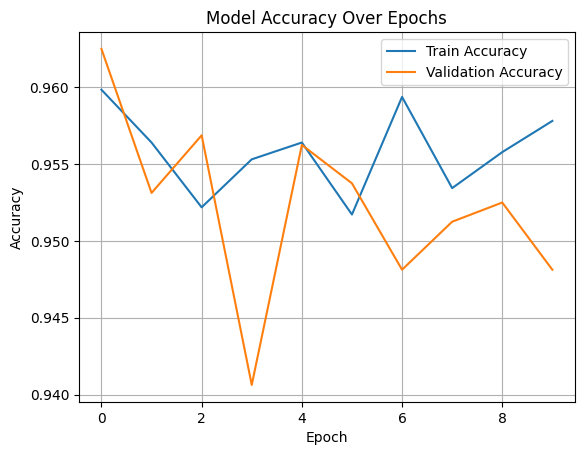

In [16]:


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


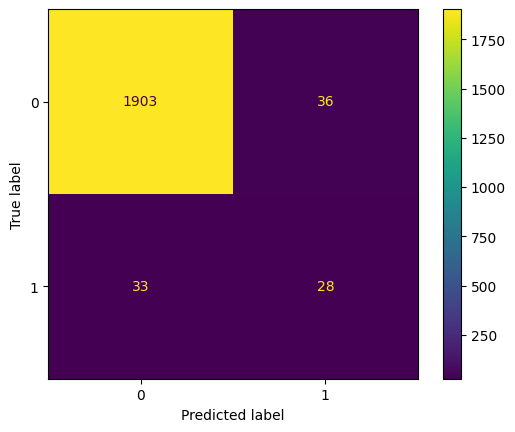

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(X_test).flatten()
y_pred_labels = np.where(y_pred > 0.5, 1, 0)

cm = confusion_matrix(y_test, y_pred_labels)
ConfusionMatrixDisplay(cm).plot()

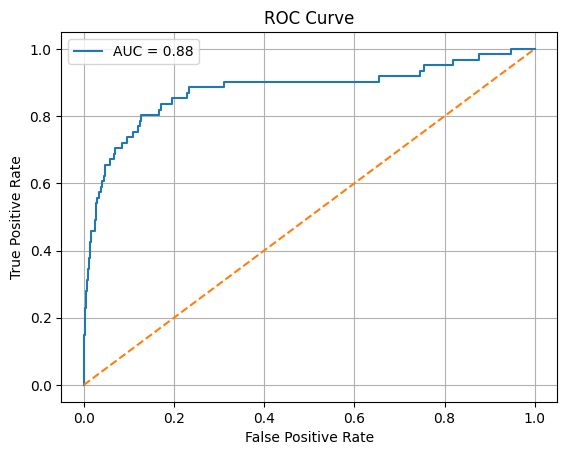

In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
results = pd.DataFrame({
    "Prediction": y_pred_labels,
    "True Label": y_test.reset_index(drop=True)
})
results.to_csv("../results/predictions.csv", index=False)

In [20]:
recall = recall_score(y_test, y_pred_labels)
print(f"Failure recall: {recall:.4f}")

Failure recall: 0.4590


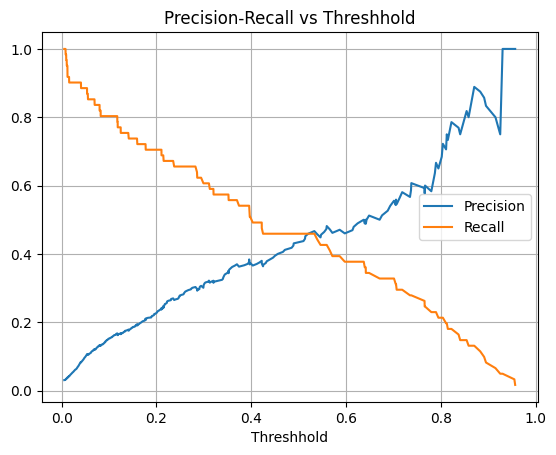

In [21]:
threshold = 0.3
y_pred_labels = (y_pred > threshold).astype(int)

# Compute precision-recall pairs
prec, rec, thresholds = precision_recall_curve(y_test, y_pred)

# Plot
plt.plot(thresholds, prec[:-1], label='Precision')
plt.plot(thresholds, rec[:-1], label='Recall')
plt.xlabel("Threshhold")
plt.legend()
plt.grid(True)
plt.title("Precision-Recall vs Threshhold")
plt.show()
